In [12]:
import h5py
import numpy as np

# Path to your .mat file
mat_file = r'data\ethernet_packets.mat'

# Open with h5py
with h5py.File(mat_file, 'r') as f:
    # List all keys
    print("Keys in MAT file:", list(f.keys()))
    
    # Access packets dataset
    packets = np.array(f['packets'])  # shape: (recordLength, numFrames)
    
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

print(f"Sample Rate: {sample_rate} Hz")
print(f"Trigger Level: {trigger_level} V")
print(f"Record Length: {record_length} samples per packet")
print(f"Number of Packets: {num_frames}")

Keys in MAT file: ['#refs#', 'metadata', 'packets']
Sample Rate: 1250000000.0 Hz
Trigger Level: -0.5 V
Record Length: 250000.0 samples per packet
Number of Packets: 5.0


<Figure size 1200x600 with 0 Axes>

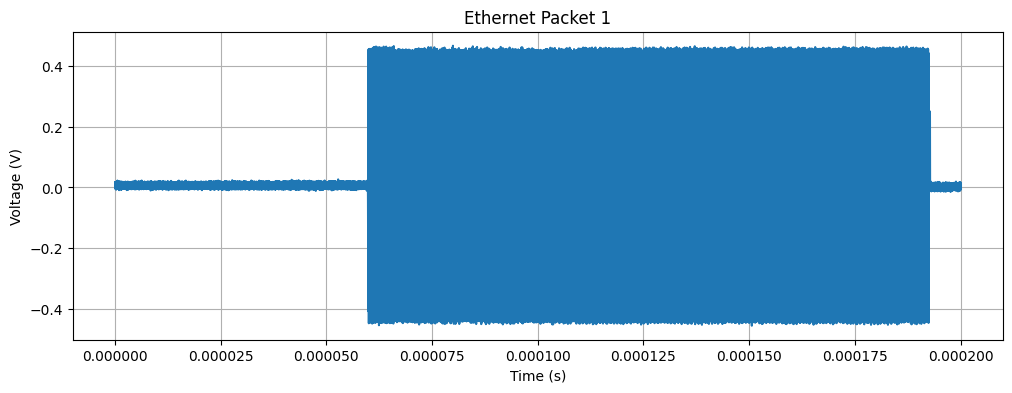

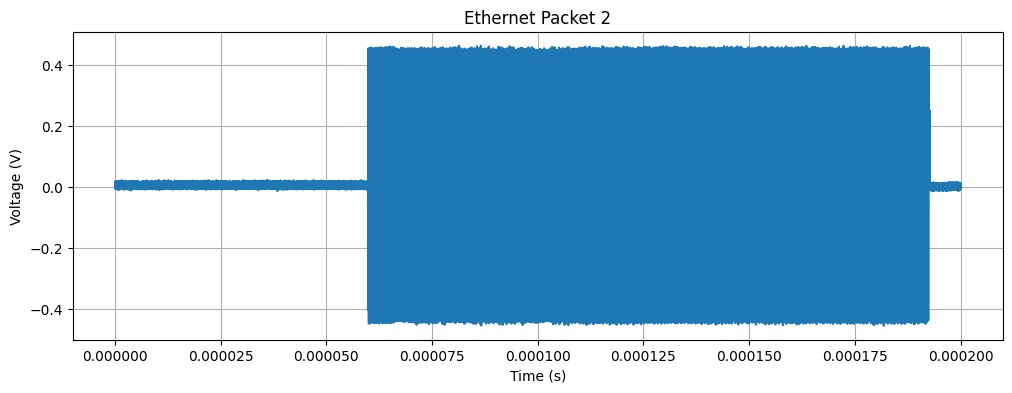

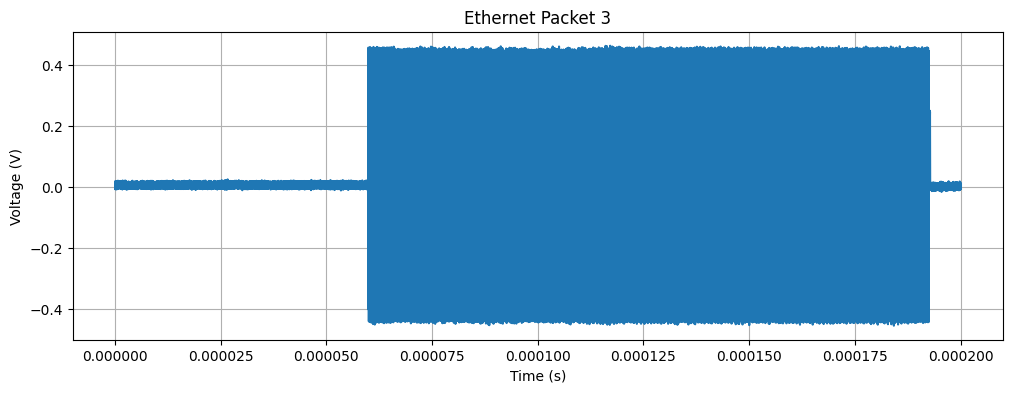

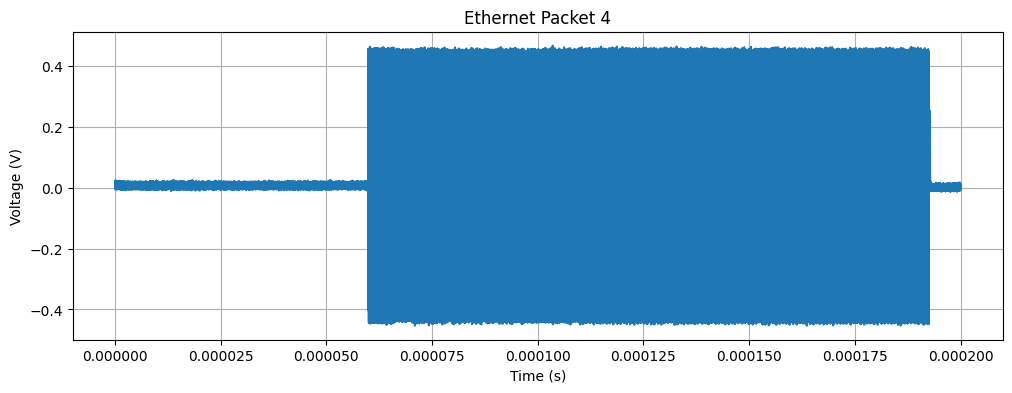

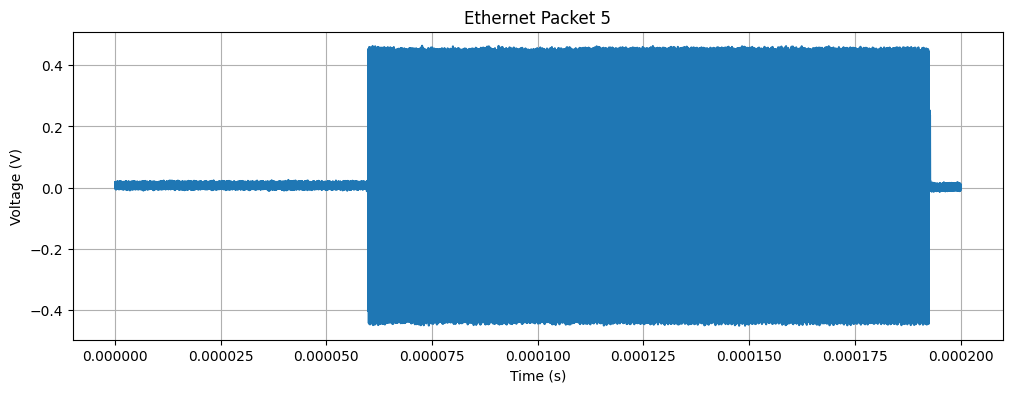

In [13]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))

for i in range(5):
    plt.figure(figsize=(12,4))
    plt.plot(time_axis, packets[i, :])
    plt.title(f'Ethernet Packet {i+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [6]:
import h5py
import numpy as np

mat_file = r'data\ethernet_packets.mat'

with h5py.File(mat_file, 'r') as f:
    # Check keys
    print("Keys:", list(f.keys()))
    
    # Read packets dataset
    packets_raw = f['packets']
    print("Raw packets shape:", packets_raw.shape)
    
    # Convert to numpy array of floats
    packets = np.array(packets_raw, dtype=np.float64)  # shape should become (recordLength, numFrames)
    
    # Read metadata attributes (if saved as attributes)
    sample_rate = f.attrs['sample_rate']
    trigger_level = f.attrs['trigger_level']
    record_length = f.attrs['record_length']
    num_frames = f.attrs['num_frames']

print(f"Packets shape: {packets.shape}")
print(f"Sample Rate: {sample_rate} Hz")

Keys: ['#refs#', 'metadata', 'packets']
Raw packets shape: (5, 250000)


KeyError: "Unable to synchronously open attribute (can't locate attribute: 'sample_rate')"